<a href="https://colab.research.google.com/github/Oskar1324/churn-prediction-project/blob/main/churn_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning: Churn Prediction – KfZ-Versicherung
In diesem Notebook entwickeln wir ein ML-Modell, das vorhersagt, ob ein Kunde
seine KfZ-Versicherung kündigt. Ziel ist es, gefährdete Kunden frühzeitig zu
erkennen, damit das Unternehmen proaktiv Maßnahmen ergreifen kann.

Die Prognosegüte wird anhand der Fläche unter der ROC-Kurve (AUC) gemessen.

# 1. Daten laden

In [1]:
# Colab: Datei hochladen
from google.colab import files

uploaded = files.upload()

Saving records.csv to records.csv


In [2]:
import pandas as pd


In [3]:
# Daten laden:

data = pd.read_csv('records.csv')

In [4]:
data.dtypes

,0
id,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,float64
Tenure,int64
NumOfProducts,int64
HasCrCard,float64


In [5]:
data.describe()

,id,CustomerId,CreditScore,Age,Tenure,NumOfProducts,HasCrCard,EstimatedSalary,Exited
count,164210.000000,1.642100e+05,164210.000000,164210.000000,164210.000000,164210.000000,164210.000000,164210.000000,164210.000000
mean,82928.500000,1.569201e+07,656.466275,38.129473,5.019840,1.554485,0.754016,112570.776646,0.211668
std,47403.488189,7.139650e+04,80.094156,8.868562,2.805613,0.547112,0.430670,50292.426883,0.408492
min,824.000000,1.556570e+07,350.000000,18.000000,0.000000,1.000000,0.000000,11.580000,0.000000
25%,41876.250000,1.563314e+07,597.000000,32.000000,3.000000,1.000000,1.000000,74593.840000,0.000000
50%,82928.500000,1.569016e+07,659.000000,37.000000,5.000000,2.000000,1.000000,117946.300000,0.000000
75%,123980.750000,1.575682e+07,710.000000,42.000000,7.000000,2.000000,1.000000,155126.037500,0.000000
max,165033.000000,1.581569e+07,850.000000,92.000000,10.000000,4.000000,1.000000,199992.480000,1.000000


# 2. Datensatz in Features und Target teilen

In [6]:
# Features: alles außer CustomerId, Surname und Exited
X = data.drop(columns=['CustomerId', 'Surname', 'Exited'])
X.head()



,id,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,EstimatedSalary
0,824,593,Germany,Male,48.0,10,1,1.0,178747.43
1,825,660,Germany,Female,36.0,2,1,1.0,110252.53
2,826,667,France,Female,36.0,6,2,0.0,120115.50
3,827,484,France,Male,33.0,0,1,0.0,42437.75
4,828,547,France,Female,50.0,1,1,1.0,135961.01


In [7]:
# Target, d.h. was soll prognostiziert werden: Exited(Ob der Kunde die Versicherung gekündigt hat (1 = ja, 0 = nein) )
y = data['Exited']
y.head()

,Exited
0,1
1,1
2,0
3,0
4,1


# 2.2 Datensatz in Trainings- und Testmenge aufteilen

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
# X und y werden in Trainings- und Testmenge aufgeteilt, so dass die Testmenge 20% der vorhandenen Daten hat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

In [10]:
y_train.head()

,Exited
26553,0
149982,0
46327,0
121353,1
142844,0


In [11]:
X_train.head()

,id,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,EstimatedSalary
26553,27377,573,France,Male,40.0,4,1,1.0,110454.46
149982,150806,652,France,Male,30.0,2,2,0.0,77783.35
46327,47151,817,France,Male,55.0,2,2,1.0,95941.55
121353,122177,682,France,Female,47.0,10,1,1.0,66528.00
142844,143668,703,Germany,Male,25.0,10,1,1.0,125870.74


# 2.3 Modell auswählen

In [12]:
from sklearn.ensemble import GradientBoostingClassifier

In [13]:
model = GradientBoostingClassifier(random_state=42)

# 2.4 Modell trainieren

Das Random Forest Verfahren versucht nun einen Zusammenhang zwischen den Features und dem Target zu lernen und minimiert dabei ein Fehlermaß. Letzteres misst den Grad der Fehlklassifikation. Beispiel für Fehlklassifikation: Das Modell prognostiziert Diabetes für einen Patienten, in der Realität liegt die Erkrankung aber nicht vor.

In [14]:
import pandas as pd

# Convert categorical features to numerical using one-hot encoding
# The .copy() is important to avoid SettingWithCopyWarning
X_train_encoded = pd.get_dummies(X_train.copy(), columns=['Geography', 'Gender'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test.copy(), columns=['Geography', 'Gender'], drop_first=True)

# Align columns - crucial step to ensure both dataframes have the same columns in the same order
# Get all columns from X_train_encoded
train_cols = X_train_encoded.columns

# Reindex X_test_encoded to match the columns of X_train_encoded, filling missing columns with 0
X_test_encoded = X_test_encoded.reindex(columns=train_cols, fill_value=0)

model.fit(X_train_encoded, y_train)

GradientBoostingClassifier(random_state=42)

# 2.5 Modell anwenden
Das ML-Verfahren erhält die Daten X_test, d.h. die Untersuchungsergebnisse mit den relevanten Merkmalen und wendet die gelernten Zusammenhänge zur Prognose des Targets an, d.h. dem Vorhandensein von Diabetes (0/1)!

In [15]:
X_test.head()

,id,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,EstimatedSalary
139734,140558,627,Spain,Female,39.0,9,2,1.0,56875.62
75939,76763,682,France,Male,33.0,1,2,1.0,174094.24
149600,150424,712,Germany,Male,39.0,1,2,1.0,65864.40
68641,69465,506,Germany,Male,29.0,0,2,1.0,166520.96
151910,152734,611,France,Male,41.0,9,2,0.0,128600.49


In [16]:
y_pred = model.predict(X_test_encoded)

In [17]:
y_pred[:5]

array([0, 0, 0, 0, 0])

In [18]:
y_test.values[:5]

array([1, 0, 0, 0, 0])

In [19]:
pd.DataFrame({"Vorhersage":pd.Series(y_pred), "Beobachtung":pd.Series(y_test.values)},).head(10)

,Vorhersage,Beobachtung
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


# 2.6 Modell evaluieren
Die Modellbewertung erfolgt bei der Klassifikation regelmäßg nach dem Kriterium der "Accuracy" (andere kommen aber auch zum Einsatz). Die Accuracy setzt die Anzahl der korrekten Klassifikation in das Verhältnis zur Anzahl aller Beobachtungen. Dementsprechend stellt sie den Anteil der korrekten Klassifikationen dar.

In [20]:
from sklearn import metrics
import matplotlib.pyplot as plt

In [21]:
metrics.accuracy_score(y_test, y_pred) * 100

85.11966384507643

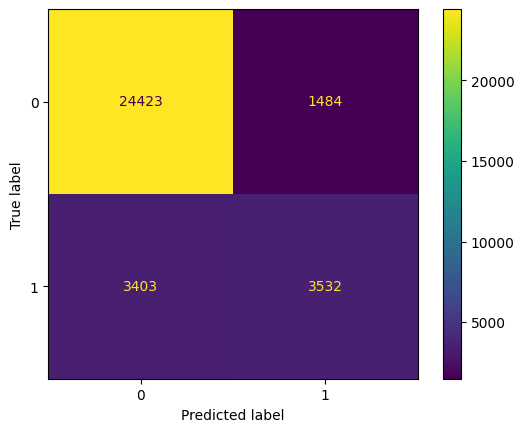

In [22]:
conf_matrix = metrics.confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = metrics.ConfusionMatrixDisplay(conf_matrix, display_labels=model.classes_)
disp.plot()
plt.show()

In [23]:
from sklearn.inspection import permutation_importance
import numpy as np

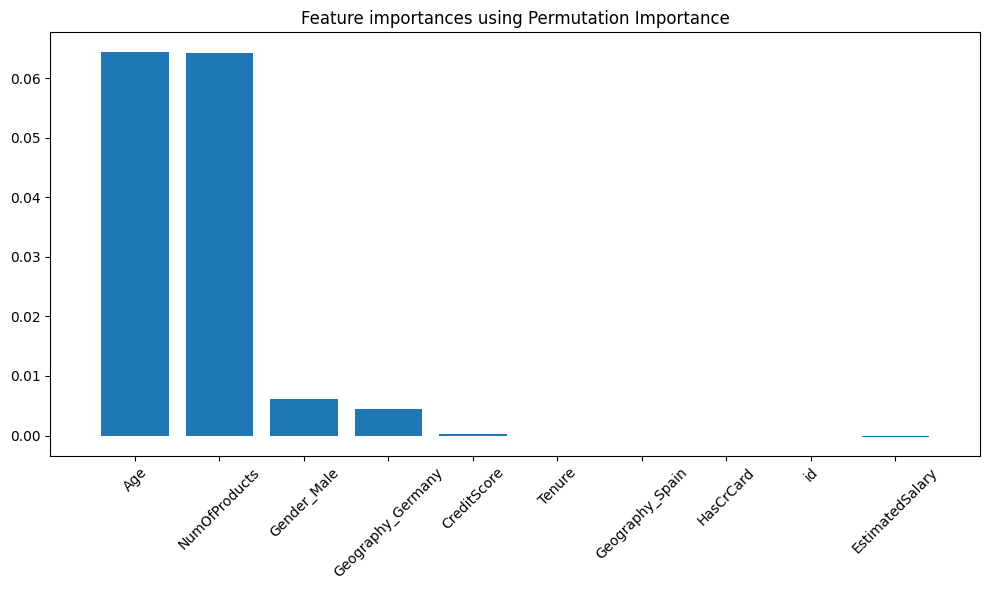

In [24]:
results = permutation_importance(model, X_test_encoded, y_test, n_repeats=10, random_state=42)
# Get the mean importance of each feature
importances = results.importances_mean

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature importances using Permutation Importance")
plt.bar(range(X_test_encoded.shape[1]), importances[indices], align="center")
plt.xticks(range(X_test_encoded.shape[1]), X_test_encoded.columns[indices], rotation=45)
plt.xlim([-1, X_test_encoded.shape[1]])
plt.tight_layout()
plt.show()

# 3 ROC-Kurve erstellen

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

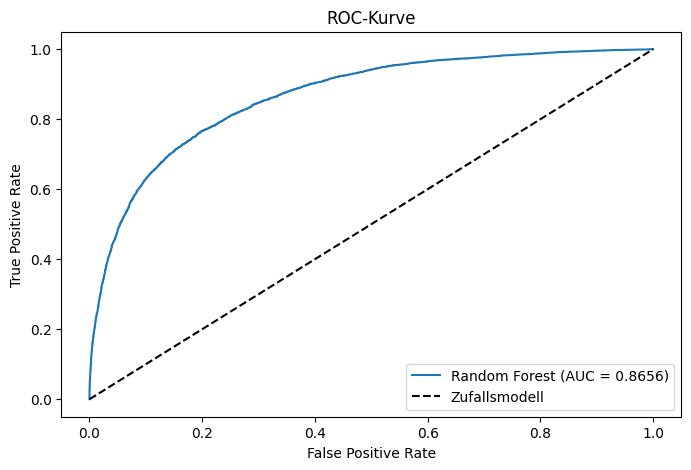

In [27]:
y_prob = model.predict_proba(X_test_encoded)[:, 1]
auc = metrics.roc_auc_score(y_test, y_prob)

# ROC-Kurve plotten
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Zufallsmodell")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-Kurve")
plt.legend()
plt.show()

In [28]:
# AUC berechnen – dafür brauchen wir Wahrscheinlichkeiten, nicht nur 0/1
y_prob = model.predict_proba(X_test_encoded)[:, 1]

auc = metrics.roc_auc_score(y_test, y_prob)
print(f"AUC-Wert: {auc * 100:.2f}%")

AUC-Wert: 86.56%


# 3.1 Parameteroptimierung
Um den AUC-Wert weiter zu maximieren, optimieren wir die Hyperparameter
des Modells mit GridSearchCV. Diese Methode testet systematisch verschiedene
Parameterkombinationen und wählt die beste anhand der AUC aus.

In [29]:
from sklearn.model_selection import GridSearchCV

# Parameterkombinationen die getestet werden sollen
param_grid = {
    "n_estimators": [100, 200],
    "max_depth":    [3, 5],
    "learning_rate": [0.05, 0.1]
}

# GridSearch mit AUC als Gütekriterium
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring="roc_auc",   # ← optimiert direkt auf AUC!
    cv=3                 # 3-fache Kreuzvalidierung
)

grid_search.fit(X_train_encoded, y_train)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [30]:
# Beste Parameter und bester AUC-Wert
print("Beste Parameter:", grid_search.best_params_)
print("Bester AUC (Training):", grid_search.best_score_.round(4))

Beste Parameter: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Bester AUC (Training): 0.8641


In [31]:
# Optimiertes Modell auf Testdaten evaluieren
best_model = grid_search.best_estimator_

y_prob_opt = best_model.predict_proba(X_test_encoded)[:, 1]
auc_opt    = metrics.roc_auc_score(y_test, y_prob_opt)

print(f"AUC vor Optimierung:  {auc:.4f}")
print(f"AUC nach Optimierung: {auc_opt:.4f}")

AUC vor Optimierung:  0.8656
AUC nach Optimierung: 0.8660


# 3.2 ROC-Kurve mit optimiertem Modell

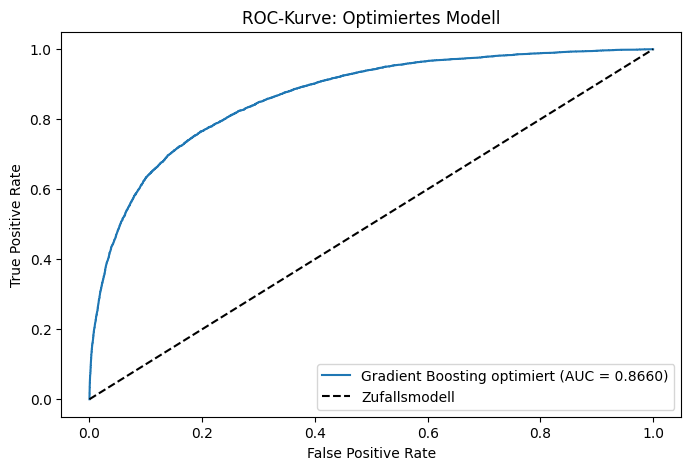

In [32]:
# ROC-Kurve mit optimiertem Modell
y_prob_opt = best_model.predict_proba(X_test_encoded)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob_opt)

auc_opt = metrics.roc_auc_score(y_test, y_prob_opt)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"Gradient Boosting optimiert (AUC = {auc_opt:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Zufallsmodell")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-Kurve: Optimiertes Modell")
plt.legend()
plt.show()